# FC-TFI QRC on ENSO (multivariate next-step)

Continuous FC-TFI quantum reservoir (no rewind cutoff, no drive reset) for three-variable ENSO next-step forecasting.

**Data (Hamhoum et al. 2026):**
- 1000 samples, $\Delta t=0.1$, adaptive RK45 (`scipy.integrate.solve_ivp`)
- Variables ordered $(u,T_w,T_e)$ and parameters $B=940$, $\Delta x=7.5$, $C=3$, $u^*=-14.2$, $\bar T=16$, $A=1$, $T^*=28$
- Initial state $(u_0,T_{w,0},T_{e,0})=(-14.2,28,28)$, no generator burn-in
- Chronological 80/20 split; per-variable min–max fit on train only; encoding clips to $[0,1]$

**QRC (our FC-TFI, not the paper's Opt-NN-TFI / rewind protocol):**
- 3 drive + 5 hidden = 8 qubits; encode $u_i\mapsto RY(\pi u_i)$ on drive qubits
- Continuous state (no reset / no washout); $J\sim\mathcal{N}(0,0.5)$, $h=0.1$, $t=0.5$, 2 layers, 3 Trotter steps
- Backends: noiseless statevector + amplitude damping ($\gamma=10^{-3}$)

**Pipeline**
1. Generate and scale ENSO; form next-step pairs $H[t]\to U[t+1]$
2. Run FC-TFI on both backends with 3 matched coupling seeds
3. Compare persistence and multivariate delay-Ridge baselines
4. Compute noiseless per-drive OTOC and multivariate STM diagnostics

In [1]:
# ── Imports and configuration ────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import optuna
from scipy.integrate import solve_ivp
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, DensityMatrix, SparsePauliOp, Operator
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, amplitude_damping_error
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler

optuna.logging.set_verbosity(optuna.logging.WARNING)
np.set_printoptions(precision=4, suppress=True)

QRC_CONFIG = {
    "n_drive_qubits": 3,
    "n_hidden_qubits": 5,
    "num_layers_per_event": 2,
    "n_iterations": 3,
    "random_seed": 42,
    "amplitude_damping_gamma": 1e-3,
    "J_std": 0.5,
    "h": 0.1,
    "t": 0.5,
    "n_trotter_steps": 3,
}

ENSO_CONFIG = {
    "T": 1000,
    "dt": 0.1,
    "B": 940.0,
    "delta_x": 7.5,
    "C": 3.0,
    "u_star": -14.2,
    "T_bar": 16.0,
    "A": 1.0,
    "T_star": 28.0,
    "x0": (-14.2, 28.0, 28.0),
    "rtol": 1e-9,
    "atol": 1e-12,
    "train_frac": 0.8,
    "var_names": ("u", "T_w", "T_e"),
}

BASELINE_CONFIG = {"delay": 10}
OTOC_CONFIG = {"n_steps": 40}
BACKENDS_TO_RUN = ("statevector", "amplitude_damping")

n_qubits = QRC_CONFIG["n_drive_qubits"] + QRC_CONFIG["n_hidden_qubits"]
assert QRC_CONFIG["n_drive_qubits"] == 3
assert n_qubits == 8

print(f"n_qubits: {n_qubits} (drive=3, hidden=5)")
print("QRC_CONFIG:", QRC_CONFIG)
print("ENSO_CONFIG:", ENSO_CONFIG)

n_qubits: 8 (drive=3, hidden=5)
QRC_CONFIG: {'n_drive_qubits': 3, 'n_hidden_qubits': 5, 'num_layers_per_event': 2, 'n_iterations': 3, 'random_seed': 42, 'amplitude_damping_gamma': 0.001, 'J_std': 0.5, 'h': 0.1, 't': 0.5, 'n_trotter_steps': 3}
ENSO_CONFIG: {'T': 1000, 'dt': 0.1, 'B': 940.0, 'delta_x': 7.5, 'C': 3.0, 'u_star': -14.2, 'T_bar': 16.0, 'A': 1.0, 'T_star': 28.0, 'x0': (-14.2, 28.0, 28.0), 'rtol': 1e-09, 'atol': 1e-12, 'train_frac': 0.8, 'var_names': ('u', 'T_w', 'T_e')}


ENSO: T=1000, raw train/test=800/200, next-step train/test=799/200
Encoding-only clipping: below=0, above=0 of 3000
Raw min: [-225.4072    5.17      3.9756] raw max: [178.9311  32.6783  28.6192]
Train-scaled min/max: [0. 0. 0.] [1. 1. 1.]


cell_2:97: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


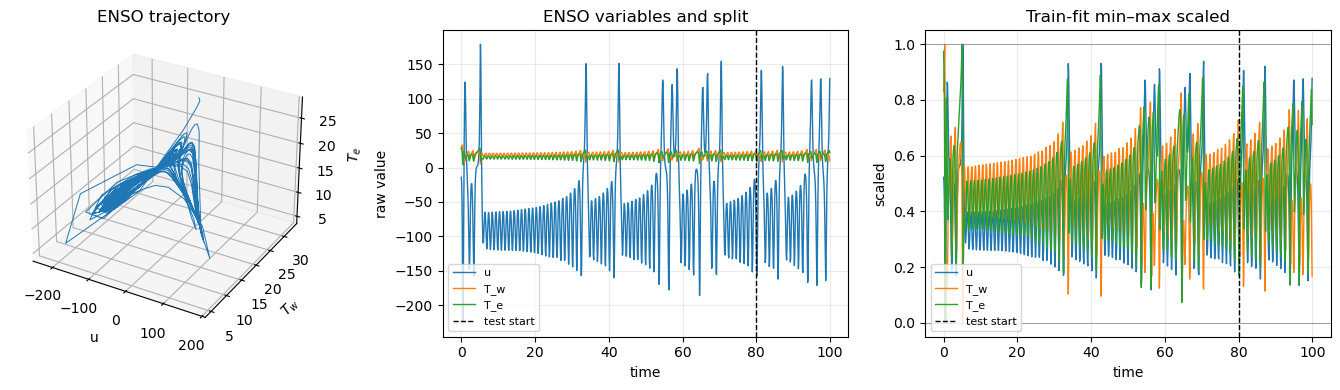

In [2]:
# ── ENSO generator (adaptive RK45) and chronological preprocessing ───────────
def enso_rhs(t, state, B, delta_x, C, u_star, T_bar, A, T_star):
    """Paper's ENSO system in state order (u, T_w, T_e)."""
    u, T_w, T_e = state
    du = B / (2.0 * delta_x) * (T_e - T_w) - C * (u - u_star)
    dT_w = u / (2.0 * delta_x) * (T_bar - T_e) - A * (T_w - T_star)
    dT_e = u / (2.0 * delta_x) * (T_w - T_bar) - A * (T_e - T_star)
    return [du, dT_w, dT_e]


def generate_enso(config):
    T, dt = config["T"], config["dt"]
    t_eval = np.arange(T, dtype=float) * dt
    args = (
        config["B"], config["delta_x"], config["C"], config["u_star"],
        config["T_bar"], config["A"], config["T_star"],
    )
    sol = solve_ivp(
        enso_rhs,
        (t_eval[0], t_eval[-1]),
        np.asarray(config["x0"], dtype=float),
        t_eval=t_eval,
        method="RK45",
        rtol=config["rtol"],
        atol=config["atol"],
        args=args,
        dense_output=False,
    )
    assert sol.success, f"RK45 failed: {sol.message}"
    U = sol.y.T.astype(float)
    assert U.shape == (T, 3)
    assert np.all(np.isfinite(U))
    assert np.allclose(sol.t, t_eval)
    assert np.allclose(U[0], config["x0"])
    return t_eval, U


t_enso, U_raw = generate_enso(ENSO_CONFIG)
n_train = int(ENSO_CONFIG["T"] * ENSO_CONFIG["train_frac"])
n_test = ENSO_CONFIG["T"] - n_train
assert (n_train, n_test) == (800, 200)

scaler = MinMaxScaler().fit(U_raw[:n_train])
U_scaled = scaler.transform(U_raw)
U_enc = np.clip(U_scaled, 0.0, 1.0)
n_clip_below = int(np.sum(U_scaled < 0.0))
n_clip_above = int(np.sum(U_scaled > 1.0))

# Feature after encoding time t predicts U[t+1].
U_drive = U_enc[:-1]
Y_target = U_scaled[1:]
n_tr_pairs = n_train - 1
n_te_pairs = n_test
U_tr, U_te = U_drive[:n_tr_pairs], U_drive[n_tr_pairs:]
Y_tr, Y_te = Y_target[:n_tr_pairs], Y_target[n_tr_pairs:]

assert U_drive.shape == (999, 3)
assert Y_target.shape == (999, 3)
assert U_tr.shape == Y_tr.shape == (799, 3)
assert U_te.shape == Y_te.shape == (200, 3)
assert np.allclose(scaler.data_min_, U_raw[:n_train].min(axis=0))
assert np.allclose(scaler.data_max_, U_raw[:n_train].max(axis=0))

print(
    f"ENSO: T={len(U_raw)}, raw train/test={n_train}/{n_test}, "
    f"next-step train/test={n_tr_pairs}/{n_te_pairs}"
)
print(f"Encoding-only clipping: below={n_clip_below}, above={n_clip_above} of {U_scaled.size}")
print("Raw min:", U_raw.min(axis=0), "raw max:", U_raw.max(axis=0))
print("Train-scaled min/max:", U_scaled[:n_train].min(axis=0), U_scaled[:n_train].max(axis=0))

# Dataset visual checks.
fig = plt.figure(figsize=(14, 4))
ax = fig.add_subplot(1, 3, 1, projection="3d")
ax.plot(U_raw[:, 0], U_raw[:, 1], U_raw[:, 2], lw=0.7)
ax.set(xlabel="u", ylabel="$T_w$", zlabel="$T_e$", title="ENSO trajectory")

ax = fig.add_subplot(1, 3, 2)
for i, name in enumerate(ENSO_CONFIG["var_names"]):
    ax.plot(t_enso, U_raw[:, i], label=name, lw=1)
ax.axvline(t_enso[n_train], color="k", ls="--", lw=1, label="test start")
ax.set(xlabel="time", ylabel="raw value", title="ENSO variables and split")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

ax = fig.add_subplot(1, 3, 3)
for i, name in enumerate(ENSO_CONFIG["var_names"]):
    ax.plot(t_enso, U_scaled[:, i], label=name, lw=1)
ax.axvline(t_enso[n_train], color="k", ls="--", lw=1, label="test start")
ax.axhline(0, color="gray", lw=0.5)
ax.axhline(1, color="gray", lw=0.5)
ax.set(xlabel="time", ylabel="scaled", title="Train-fit min–max scaled")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

In [3]:
# ── Continuous multivariate FC-TFI reservoir ─────────────────────────────────
def generate_ising_params(n_qubits, rng, J_std=0.5, h=0.1, t=0.5):
    J = np.zeros((n_qubits, n_qubits))
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            J[i, j] = rng.normal(0.0, J_std)
    return J, h, t


def trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=3):
    dt = t / n_trotter_steps
    for _ in range(n_trotter_steps):
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                if abs(J[i, j]) > 1e-10:
                    qc.cx(i, j)
                    qc.rz(2.0 * J[i, j] * dt, j)
                    qc.cx(i, j)
        for i in range(n_qubits):
            qc.rx(2.0 * h * dt, i)


def u_to_theta(u):
    return float(np.clip(u, 0.0, 1.0) * np.pi)


def encode_drive(qc, thetas, n_drive_qubits):
    thetas = np.asarray(thetas, dtype=float).reshape(-1)
    assert len(thetas) == n_drive_qubits
    for i, theta in enumerate(thetas):
        qc.ry(theta, i)


def build_event_step_circuit(
    thetas, ising_params, num_layers, n_qubits, n_drive_qubits,
    apply_initial_h, n_trotter_steps=3,
):
    J, h, t = ising_params
    qc = QuantumCircuit(n_qubits)
    if apply_initial_h:
        for i in range(n_qubits):
            qc.h(i)
    encode_drive(qc, thetas, n_drive_qubits)
    for _ in range(num_layers):
        trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps)
        encode_drive(qc, thetas, n_drive_qubits)
        trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps)
    return qc


def pauli_string(n_qubits, basis, qubit):
    label = ["I"] * n_qubits
    label[n_qubits - 1 - qubit] = basis
    return "".join(label)


def pauli_expectations(state, n_qubits):
    one_body = np.zeros(3 * n_qubits)
    for basis_idx, basis in enumerate(("Z", "X", "Y")):
        for q in range(n_qubits):
            op = SparsePauliOp(pauli_string(n_qubits, basis, q))
            one_body[basis_idx * n_qubits + q] = state.expectation_value(op).real
    zz = np.zeros(n_qubits)
    for i in range(n_qubits):
        j = (i + 1) % n_qubits
        label = ["I"] * n_qubits
        label[n_qubits - 1 - i] = "Z"
        label[n_qubits - 1 - j] = "Z"
        zz[i] = state.expectation_value(SparsePauliOp("".join(label))).real
    return np.concatenate([one_body, zz])


def build_amplitude_damping_noise_model(gamma):
    if gamma <= 0.0:
        return None
    noise_model = NoiseModel()
    err1 = amplitude_damping_error(gamma)
    for gate in ("ry", "rx", "rz", "h", "id"):
        noise_model.add_all_qubit_quantum_error(err1, [gate])
    noise_model.add_all_qubit_quantum_error(err1.tensor(err1), ["cx"])
    return noise_model


def make_aer_density_simulator(gamma, seed=42):
    noise_model = build_amplitude_damping_noise_model(gamma)
    kwargs = {"method": "density_matrix", "seed_simulator": seed}
    if noise_model is not None:
        kwargs["noise_model"] = noise_model
    return AerSimulator(**kwargs)


def aer_evolve_density_matrix(sim, rho, step_circuit, n_qubits):
    qc = QuantumCircuit(n_qubits)
    qc.set_density_matrix(rho)
    qc.compose(step_circuit, inplace=True)
    qc.save_density_matrix(label="rho")
    tqc = transpile(qc, sim)
    rho_out = sim.run(tqc, shots=1).result().data(0)["rho"]
    return rho_out if isinstance(rho_out, DensityMatrix) else DensityMatrix(rho_out)


def run_quantum_reservoir(u_series, ising_params, config, backend, aer_sim=None):
    """Process one full trajectory without drive resets or a train/test reset."""
    n_drive = config["n_drive_qubits"]
    n_total = n_drive + config["n_hidden_qubits"]
    u_series = np.asarray(u_series, dtype=float)
    assert u_series.ndim == 2 and u_series.shape[1] == n_drive
    H = np.zeros((len(u_series), 4 * n_total))

    if backend == "statevector":
        state = Statevector.from_label("0" * n_total)
    elif backend == "amplitude_damping":
        state = DensityMatrix.from_label("0" * n_total)
        aer_sim = aer_sim or make_aer_density_simulator(
            config["amplitude_damping_gamma"], config["random_seed"]
        )
    else:
        raise ValueError(f"Unknown backend: {backend}")

    for i, u_vec in enumerate(u_series):
        step = build_event_step_circuit(
            [u_to_theta(u) for u in u_vec],
            ising_params,
            config["num_layers_per_event"],
            n_total,
            n_drive,
            apply_initial_h=(i == 0),
            n_trotter_steps=config["n_trotter_steps"],
        )
        if backend == "statevector":
            state = state.evolve(step)
        else:
            state = aer_evolve_density_matrix(aer_sim, state, step, n_total)
        H[i] = pauli_expectations(state, n_total)
        if i % 100 == 0:
            print(f"  sample {i + 1}/{len(u_series)}", end="\r")
    print()
    assert H.shape == (len(u_series), 4 * n_total)
    assert np.all(np.isfinite(H))
    return H, state

In [4]:
# ── Multi-output Ridge readout and QRC experiment ────────────────────────────
def nmse(y_true, y_pred):
    yt = np.asarray(y_true, dtype=float).ravel()
    yp = np.asarray(y_pred, dtype=float).ravel()
    variance = np.var(yt)
    return np.nan if variance < 1e-15 else float(mean_squared_error(yt, yp) / variance)


def regression_metrics(y_true, y_pred, names):
    yt, yp = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    assert yt.shape == yp.shape and yt.ndim == 2
    return {
        "mse": float(mean_squared_error(yt, yp)),
        "mse_per_var": {name: float(mean_squared_error(yt[:, i], yp[:, i])) for i, name in enumerate(names)},
        "nmse": nmse(yt, yp),
        "nmse_per_var": {name: nmse(yt[:, i], yp[:, i]) for i, name in enumerate(names)},
        "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
        "mae": float(mean_absolute_error(yt, yp)),
        "r2": float(r2_score(yt, yp)),
    }


def fit_ridge_timeseries(X_train, y_train, seed=42, n_trials=30):
    def cv_mse(alpha):
        fold_mses = []
        for tr, va in TimeSeriesSplit(n_splits=3).split(X_train):
            model = Ridge(alpha=alpha).fit(X_train[tr], y_train[tr])
            fold_mses.append(mean_squared_error(y_train[va], model.predict(X_train[va])))
        return float(np.mean(fold_mses))

    def objective(trial):
        return cv_mse(trial.suggest_float("alpha", 1e-4, 1e6, log=True))

    study = optuna.create_study(
        direction="minimize", sampler=optuna.samplers.TPESampler(seed=seed)
    )
    study.optimize(objective, n_trials=n_trials)
    alpha = study.best_params["alpha"]
    return Ridge(alpha=alpha).fit(X_train, y_train), {
        "alpha": alpha,
        "cv_mse": float(study.best_value),
    }


def run_enso_qrc(backend):
    names = ENSO_CONFIG["var_names"]
    results, predictions, artifacts = [], [], []
    for iteration in range(QRC_CONFIG["n_iterations"]):
        print(f"\n=== ENSO | {backend} | iter {iteration + 1}/{QRC_CONFIG['n_iterations']} ===")
        rng = np.random.default_rng(QRC_CONFIG["random_seed"] + 17 * iteration)
        ising = generate_ising_params(
            n_qubits, rng, QRC_CONFIG["J_std"], QRC_CONFIG["h"], QRC_CONFIG["t"]
        )
        sim = None
        if backend == "amplitude_damping":
            sim = make_aer_density_simulator(
                QRC_CONFIG["amplitude_damping_gamma"],
                QRC_CONFIG["random_seed"] + iteration,
            )
        print("  reservoir (full continuous drive)...")
        H_full, _ = run_quantum_reservoir(U_drive, ising, QRC_CONFIG, backend, sim)
        H_train, H_test = H_full[:n_tr_pairs], H_full[n_tr_pairs:]
        model, fit_info = fit_ridge_timeseries(
            H_train, Y_tr, seed=QRC_CONFIG["random_seed"] + iteration
        )
        prediction = model.predict(H_test)
        scaled = regression_metrics(Y_te, prediction, names)
        raw = regression_metrics(
            scaler.inverse_transform(Y_te), scaler.inverse_transform(prediction), names
        )
        record = {
            "iteration": iteration,
            "alpha": fit_info["alpha"],
            "cv_mse": fit_info["cv_mse"],
            "test_mse": scaled["mse"],
            "test_mse_per_var": scaled["mse_per_var"],
            "test_nmse": scaled["nmse"],
            "test_nmse_per_var": scaled["nmse_per_var"],
            "test_rmse_raw": raw["rmse"],
            "test_mae_raw": raw["mae"],
            "test_r2_raw": raw["r2"],
            "yhat": prediction,
            "ising": ising,
        }
        results.append(record)
        predictions.append(prediction)
        artifacts.append({
            "ising": ising,
            "H_train": H_train,
            "H_test": H_test,
            "U_train": U_drive[:n_tr_pairs],
            "backend": backend,
        })
        print(
            f"  alpha={record['alpha']:.3g} | MSE={record['test_mse']:.5f} | "
            f"NMSE={record['test_nmse']:.4f} | raw RMSE={record['test_rmse_raw']:.4f}"
        )

    ensemble = np.mean(np.stack(predictions), axis=0)
    ensemble_scaled = regression_metrics(Y_te, ensemble, names)
    ensemble_raw = regression_metrics(
        scaler.inverse_transform(Y_te), scaler.inverse_transform(ensemble), names
    )
    seed_mses = np.array([r["test_mse"] for r in results])
    summary = {
        "backend": backend,
        "seed_mse_mean": float(seed_mses.mean()),
        "seed_mse_std": float(seed_mses.std(ddof=0)),
        "ensemble_mse": ensemble_scaled["mse"],
        "ensemble_mse_per_var": ensemble_scaled["mse_per_var"],
        "ensemble_nmse": ensemble_scaled["nmse"],
        "ensemble_nmse_per_var": ensemble_scaled["nmse_per_var"],
        "ensemble_rmse_raw": ensemble_raw["rmse"],
        "ensemble_mae_raw": ensemble_raw["mae"],
        "ensemble_r2_raw": ensemble_raw["r2"],
        "y_test": Y_te,
        "yhat": ensemble,
        "results": results,
        "artifacts": artifacts,
    }
    print(
        f"Ensemble ENSO/{backend}: MSE={summary['ensemble_mse']:.5f} "
        f"(seed mean±std={summary['seed_mse_mean']:.5f}±{summary['seed_mse_std']:.5f}) | "
        f"raw RMSE={summary['ensemble_rmse_raw']:.4f}"
    )
    return summary

In [5]:
# ── Run both QRC backends with matched coupling seeds ────────────────────────
enso_summaries = {backend: run_enso_qrc(backend) for backend in BACKENDS_TO_RUN}

for iteration in range(QRC_CONFIG["n_iterations"]):
    J_sv = enso_summaries["statevector"]["results"][iteration]["ising"][0]
    J_ad = enso_summaries["amplitude_damping"]["results"][iteration]["ising"][0]
    assert np.array_equal(J_sv, J_ad), f"Unmatched J at seed {iteration}"

print("\n======== ENSO QRC summary ========")
print(f"{'backend':<20} {'seed MSE mean±std':>24} {'ensemble MSE':>14} {'raw RMSE':>12} {'raw R2':>10}")
for backend, summary in enso_summaries.items():
    seed_text = f"{summary['seed_mse_mean']:.5f}±{summary['seed_mse_std']:.5f}"
    print(
        f"{backend:<20} {seed_text:>24} {summary['ensemble_mse']:14.5f} "
        f"{summary['ensemble_rmse_raw']:12.4f} {summary['ensemble_r2_raw']:10.4f}"
    )


=== ENSO | statevector | iter 1/3 ===
  reservoir (full continuous drive)...
  sample 901/999
  alpha=9.82e+05 | MSE=0.02955 | NMSE=1.0188 | raw RMSE=45.8621

=== ENSO | statevector | iter 2/3 ===
  reservoir (full continuous drive)...
  sample 901/999
  alpha=13.7 | MSE=0.02941 | NMSE=1.0139 | raw RMSE=45.7349

=== ENSO | statevector | iter 3/3 ===
  reservoir (full continuous drive)...
  sample 901/999
  alpha=7.54 | MSE=0.02973 | NMSE=1.0251 | raw RMSE=46.1611
Ensemble ENSO/statevector: MSE=0.02953 (seed mean±std=0.02956±0.00013) | raw RMSE=45.8892

=== ENSO | amplitude_damping | iter 1/3 ===
  reservoir (full continuous drive)...
  sample 901/999
  alpha=0.000104 | MSE=0.00036 | NMSE=0.0125 | raw RMSE=3.2406

=== ENSO | amplitude_damping | iter 2/3 ===
  reservoir (full continuous drive)...
  sample 901/999
  alpha=0.000104 | MSE=0.00037 | NMSE=0.0128 | raw RMSE=3.5311

=== ENSO | amplitude_damping | iter 3/3 ===
  reservoir (full continuous drive)...
  sample 901/999
  alpha=0.00


======== ENSO model comparison ========
model                  scaled MSE   scaled NMSE     raw RMSE     raw MAE     raw R2
persistence               0.00670        0.2308      15.4880      8.8486     0.7425
  per-variable MSE: {'u': 0.004336556513706175, 'T_w': 0.007279859883764594, 'T_e': 0.008471265689745554}
delay_ridge               0.00038        0.0131       0.9826      0.6611     0.9840
  per-variable MSE: {'u': 1.29529669956275e-05, 'T_w': 0.0006456369007708375, 'T_e': 0.0004782800454696154}
statevector               0.02953        1.0180      45.8892     23.1020    -0.0471
  per-variable MSE: {'u': 0.03843521503694294, 'T_w': 0.021698516913940483, 'T_e': 0.02844844315304064}
amplitude_damping         0.00012        0.0040       1.8177      0.9318     0.9955
  per-variable MSE: {'u': 5.944146867727188e-05, 'T_w': 0.00013300522752553428, 'T_e': 0.00015410674394837685}


cell_6:105: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
cell_6:124: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


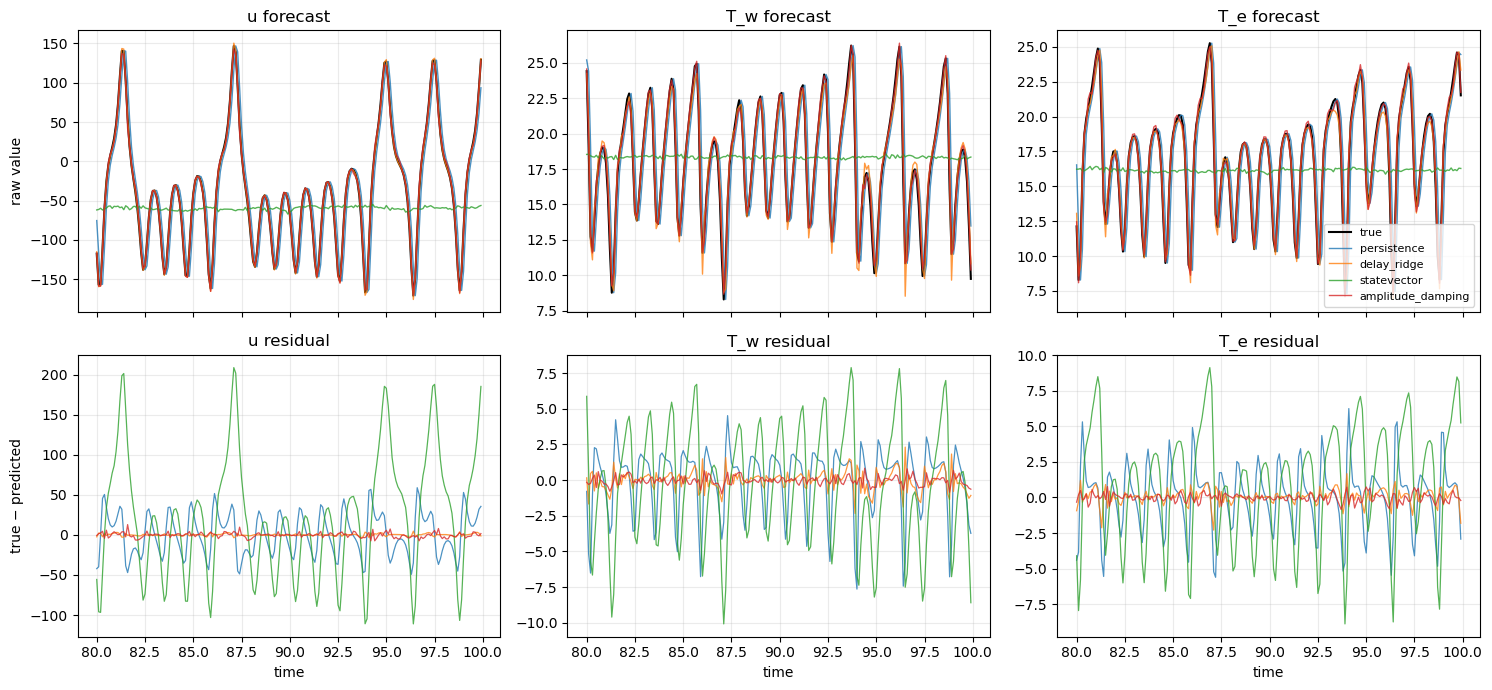

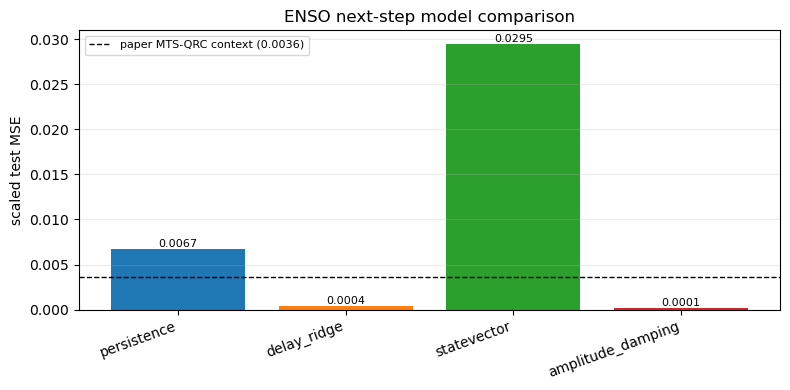

In [6]:
# ── Persistence and multivariate delay-Ridge baselines ───────────────────────
names = ENSO_CONFIG["var_names"]
true_test_raw = scaler.inverse_transform(Y_te)

persistence_pred = U_scaled[n_train - 1:-1]
assert persistence_pred.shape == Y_te.shape
persistence_scaled = regression_metrics(Y_te, persistence_pred, names)
persistence_raw = regression_metrics(
    true_test_raw, scaler.inverse_transform(persistence_pred), names
)


def delay_embedding(series, delay):
    """Rows contain [U[t], U[t-1], ..., U[t-delay]]; target is U[t+1]."""
    X, y, target_indices = [], [], []
    for t in range(delay, len(series) - 1):
        X.append(series[t - delay:t + 1][::-1].reshape(-1))
        y.append(series[t + 1])
        target_indices.append(t + 1)
    return np.asarray(X), np.asarray(y), np.asarray(target_indices)


delay = BASELINE_CONFIG["delay"]
X_delay, y_delay, target_indices = delay_embedding(U_scaled, delay)
train_mask = target_indices < n_train
test_mask = target_indices >= n_train
X_delay_train, y_delay_train = X_delay[train_mask], y_delay[train_mask]
X_delay_test, y_delay_test = X_delay[test_mask], y_delay[test_mask]
assert X_delay.shape[1] == 33
assert y_delay_test.shape == Y_te.shape == (200, 3)
assert np.allclose(y_delay_test, Y_te)

delay_model, delay_fit = fit_ridge_timeseries(
    X_delay_train, y_delay_train, seed=QRC_CONFIG["random_seed"]
)
delay_pred = delay_model.predict(X_delay_test)
delay_scaled = regression_metrics(Y_te, delay_pred, names)
delay_raw = regression_metrics(
    true_test_raw, scaler.inverse_transform(delay_pred), names
)

model_records = {
    "persistence": {
        "mse": persistence_scaled["mse"], "mse_per_var": persistence_scaled["mse_per_var"],
        "nmse": persistence_scaled["nmse"], "raw": persistence_raw, "yhat": persistence_pred,
    },
    "delay_ridge": {
        "mse": delay_scaled["mse"], "mse_per_var": delay_scaled["mse_per_var"],
        "nmse": delay_scaled["nmse"], "raw": delay_raw, "yhat": delay_pred,
    },
}
for backend, summary in enso_summaries.items():
    model_records[backend] = {
        "mse": summary["ensemble_mse"],
        "mse_per_var": summary["ensemble_mse_per_var"],
        "nmse": summary["ensemble_nmse"],
        "raw": {
            "rmse": summary["ensemble_rmse_raw"],
            "mae": summary["ensemble_mae_raw"],
            "r2": summary["ensemble_r2_raw"],
        },
        "yhat": summary["yhat"],
    }

print("\n======== ENSO model comparison ========")
print(f"{'model':<20} {'scaled MSE':>12} {'scaled NMSE':>13} {'raw RMSE':>12} {'raw MAE':>11} {'raw R2':>10}")
for model_name, record in model_records.items():
    print(
        f"{model_name:<20} {record['mse']:12.5f} {record['nmse']:13.4f} "
        f"{record['raw']['rmse']:12.4f} {record['raw']['mae']:11.4f} {record['raw']['r2']:10.4f}"
    )
    print("  per-variable MSE:", record["mse_per_var"])

# Predictions and residuals in physical units (colors match bar chart).
MODEL_COLORS = {
    "persistence": "C0",
    "delay_ridge": "C1",
    "statevector": "C2",
    "amplitude_damping": "C3",
}
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
plot_models = ("persistence", "delay_ridge", "statevector", "amplitude_damping")
test_time = t_enso[n_train:]
for col, name in enumerate(names):
    axes[0, col].plot(test_time, true_test_raw[:, col], color="black", label="true", lw=1.5)
    for model_name in plot_models:
        pred_raw = scaler.inverse_transform(model_records[model_name]["yhat"])
        color = MODEL_COLORS[model_name]
        axes[0, col].plot(
            test_time, pred_raw[:, col], label=model_name, lw=1, alpha=0.8, color=color,
        )
        axes[1, col].plot(
            test_time, true_test_raw[:, col] - pred_raw[:, col],
            label=model_name, lw=0.9, alpha=0.8, color=color,
        )
    axes[0, col].set_title(f"{name} forecast")
    axes[1, col].set_title(f"{name} residual")
    axes[1, col].set_xlabel("time")
    for row in range(2):
        axes[row, col].grid(alpha=0.25)
axes[0, 0].set_ylabel("raw value")
axes[1, 0].set_ylabel("true − predicted")
axes[0, 2].legend(fontsize=8, loc="best")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
labels = list(model_records)
vals = [model_records[label]["mse"] for label in labels]
colors = [MODEL_COLORS.get(label, f"C{i}") for i, label in enumerate(labels)]
bars = ax.bar(range(len(labels)), vals, color=colors)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=20, ha="right")
for bar, val in zip(bars, vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2, val, f"{val:.4f}",
        ha="center", va="bottom", fontsize=8,
    )
ax.axhline(0.0036, color="black", ls="--", lw=1, label="paper MTS-QRC context (0.0036)")
ax.set(ylabel="scaled test MSE", title="ENSO next-step model comparison")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

OTOC seed 1/3...
OTOC seed 2/3...
OTOC seed 3/3...

======== ENSO memory diagnostics ========
statevector          u    STM MC=1.301±0.933
statevector          T_w  STM MC=0.386±0.063
statevector          T_e  STM MC=0.609±0.237
statevector          mean STM MC=0.766
amplitude_damping    u    STM MC=4.202±0.833
amplitude_damping    T_w  STM MC=5.185±0.309
amplitude_damping    T_e  STM MC=6.348±0.811
amplitude_damping    mean STM MC=5.245
Noisy OTOC intentionally omitted: an 8-qubit dense SuperOp would require about 64 GiB.


cell_7:113: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


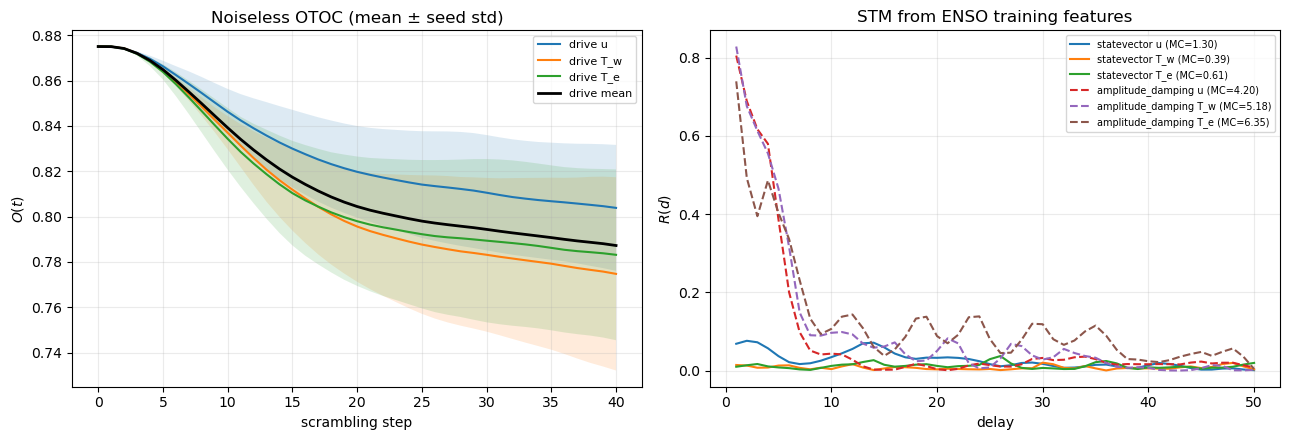

In [7]:
# ── Noiseless per-drive OTOC and multivariate STM diagnostics ────────────────
def _embed_1q(op2, qubit, n_total):
    mats = [op2 if i == qubit else np.eye(2, dtype=complex) for i in range(n_total)]
    full = np.array([[1.0]], dtype=complex)
    for i in range(n_total - 1, -1, -1):
        full = np.kron(full, mats[i])
    return full


def build_otoc_step_circuit(ising_params):
    J, h, evolution_time = ising_params
    qc = QuantumCircuit(n_qubits)
    for _ in range(QRC_CONFIG["num_layers_per_event"]):
        trotter_ising_layer(
            qc, n_qubits, J, h, evolution_time, QRC_CONFIG["n_trotter_steps"]
        )
    return qc


def otoc_all_drives(ising_params, n_steps):
    """Sagawa-style infinite-temperature OTOC for each of the 3 drive qubits."""
    U = Operator(build_otoc_step_circuit(ising_params)).data
    Udag = U.conj().T
    dim = 2 ** n_qubits
    Z = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)
    fixed = [_embed_1q(Z, q, n_qubits) for q in range(n_qubits)]
    evolved = [op.copy() for op in fixed]
    curves = np.zeros((QRC_CONFIG["n_drive_qubits"], n_steps + 1))
    for step_idx in range(n_steps + 1):
        for drive in range(QRC_CONFIG["n_drive_qubits"]):
            accumulator = 0.0
            for target in range(n_qubits):
                if target == drive:
                    continue
                z_drive, z_target = fixed[drive], evolved[target]
                accumulator += np.trace(z_drive @ z_target @ z_drive @ z_target).real / dim
            curves[drive, step_idx] = accumulator / n_qubits
        if step_idx < n_steps:
            evolved = [Udag @ op @ U for op in evolved]
    assert np.all(np.isfinite(curves))
    return curves


def stm_memory_curve(H, series, max_delay=50, alpha=1.0):
    H = np.asarray(H, dtype=float)
    series = np.asarray(series, dtype=float).reshape(-1)
    assert len(H) == len(series)
    curve = np.zeros(max_delay + 1)
    for delay_idx in range(1, max_delay + 1):
        X, y = H[delay_idx:], series[:-delay_idx]
        n_fit = int(0.7 * len(y))
        model = Ridge(alpha=alpha).fit(X[:n_fit], y[:n_fit])
        prediction, truth = model.predict(X[n_fit:]), y[n_fit:]
        if np.var(prediction) > 1e-15 and np.var(truth) > 1e-15:
            value = float(np.corrcoef(truth, prediction)[0, 1] ** 2)
            curve[delay_idx] = value if np.isfinite(value) else 0.0
    return curve, float(curve[1:].sum())


# OTOC: noiseless only; one curve per drive and matched coupling seed.
otoc_by_seed = []
for iteration, artifact in enumerate(enso_summaries["statevector"]["artifacts"]):
    print(f"OTOC seed {iteration + 1}/{QRC_CONFIG['n_iterations']}...")
    otoc_by_seed.append(otoc_all_drives(artifact["ising"], OTOC_CONFIG["n_steps"]))
otoc_by_seed = np.asarray(otoc_by_seed)
assert otoc_by_seed.shape == (3, 3, OTOC_CONFIG["n_steps"] + 1)

# STM: each variable, seed, and backend, using training features only.
stm_results = {}
for backend in BACKENDS_TO_RUN:
    curves, capacities = [], []
    for artifact in enso_summaries[backend]["artifacts"]:
        seed_curves, seed_capacities = [], []
        for variable_idx in range(3):
            curve, capacity = stm_memory_curve(
                artifact["H_train"], artifact["U_train"][:, variable_idx], max_delay=50, alpha=1.0
            )
            seed_curves.append(curve)
            seed_capacities.append(capacity)
        curves.append(seed_curves)
        capacities.append(seed_capacities)
    stm_results[backend] = {
        "curves": np.asarray(curves),
        "capacities": np.asarray(capacities),
    }
    assert stm_results[backend]["curves"].shape == (3, 3, 51)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for variable_idx, name in enumerate(names):
    mean_curve = otoc_by_seed[:, variable_idx].mean(axis=0)
    std_curve = otoc_by_seed[:, variable_idx].std(axis=0)
    steps = np.arange(len(mean_curve))
    axes[0].plot(steps, mean_curve, label=f"drive {name}")
    axes[0].fill_between(steps, mean_curve - std_curve, mean_curve + std_curve, alpha=0.15)
axes[0].plot(steps, otoc_by_seed.mean(axis=(0, 1)), color="black", lw=2, label="drive mean")
axes[0].set(xlabel="scrambling step", ylabel="$O(t)$", title="Noiseless OTOC (mean ± seed std)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

line_styles = {"statevector": "-", "amplitude_damping": "--"}
for backend in BACKENDS_TO_RUN:
    for variable_idx, name in enumerate(names):
        mean_curve = stm_results[backend]["curves"][:, variable_idx, 1:].mean(axis=0)
        mean_capacity = stm_results[backend]["capacities"][:, variable_idx].mean()
        axes[1].plot(
            np.arange(1, 51), mean_curve, ls=line_styles[backend],
            label=f"{backend} {name} (MC={mean_capacity:.2f})",
        )
axes[1].set(xlabel="delay", ylabel="$R(d)$", title="STM from ENSO training features")
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

print("\n======== ENSO memory diagnostics ========")
for backend in BACKENDS_TO_RUN:
    values = stm_results[backend]["capacities"]
    for variable_idx, name in enumerate(names):
        print(
            f"{backend:<20} {name:<4} STM MC="
            f"{values[:, variable_idx].mean():.3f}±{values[:, variable_idx].std():.3f}"
        )
    print(f"{backend:<20} mean STM MC={values.mean():.3f}")
print("Noisy OTOC intentionally omitted: an 8-qubit dense SuperOp would require about 64 GiB.")

In [8]:
# ── Final reproducibility checks ─────────────────────────────────────────────
assert ENSO_CONFIG["B"] == 940.0
assert ENSO_CONFIG["delta_x"] == 7.5
assert ENSO_CONFIG["C"] == 3.0
assert ENSO_CONFIG["u_star"] == -14.2
assert ENSO_CONFIG["T_bar"] == 16.0
assert ENSO_CONFIG["A"] == 1.0
assert ENSO_CONFIG["T_star"] == 28.0
assert ENSO_CONFIG["dt"] == 0.1 and ENSO_CONFIG["T"] == 1000
assert np.all(np.isfinite(U_raw))
assert np.all(np.isfinite(Y_te))
assert all(np.all(np.isfinite(record["yhat"])) for record in model_records.values())
assert all(
    artifact["H_train"].shape == (799, 32)
    for backend in BACKENDS_TO_RUN
    for artifact in enso_summaries[backend]["artifacts"]
)
assert len(enso_summaries["statevector"]["artifacts"]) == 3
assert len(enso_summaries["amplitude_damping"]["artifacts"]) == 3
print("All ENSO dataset, alignment, feature, backend, prediction, and diagnostic checks passed.")

All ENSO dataset, alignment, feature, backend, prediction, and diagnostic checks passed.
